# Shakespeare Text Generation with Word-Level RNN

A PyTorch implementation of a word-level RNN trained on Shakespeare's text. The model learns to generate Shakespeare-style text by predicting the next word given a sequence of previous words.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

## 1. Data Loading and Preprocessing

The dataset is Shakespeare's complete text (aroun 800K words). We tokenize at the word level, building a vocabulary of unique words and creating integer mappings for each.

In [2]:
#load and process data
with open('/kaggle/input/datasets/mohammedmohsen0404/shakespeare-txt/shakespeare.txt', 'r', encoding ='utf-8') as f:
    text = f.read()


words = text.lower().split()
words_vocab = sorted(list(set(words)))
vocab_size = len(words_vocab)

stoi = {w:i for i, w in enumerate(words_vocab)}
itos = {i:w for i, w in enumerate(words_vocab)}

def encode(s):
    return [stoi[w] for w in s.lower().split()]
def decode(l):
    return' '.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype = torch.long)

In [3]:
print(f"Total words : {len(words):,}")
print(f"Unique vocabulary : {vocab_size:,}")
print(f"Train tensor size : {data.shape}")

Total words : 1,068,193
Unique vocabulary : 61,385
Train tensor size : torch.Size([1068193])


## 2. Hyperparameters

In [4]:
#hyperparameters
block_size= 50
batch_size= 32
hidden_size= 256
num_layers = 1
lr=0.001
epochs =20000
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 3. Batch Sampling

Random batches are sampled from the corpus. Each input sequence `x` is paired with target sequence `y`, which is `x` shifted one word to the right — the standard language modeling objective.

In [5]:
#dataset
def get_batch(data, block_size, batch_size):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)
    

## 4. Model Architecture

The model consists of three components:
- **Embedding layer**: maps each word index to a dense 256-dimensional vector
- **RNN layer**: processes the sequence and maintains a hidden state
- **Linear layer**: projects hidden state back to vocabulary size for next-word prediction

In [6]:
#model
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first =True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(num_layers, batch_size, hidden_size).to(device)

## 5. Initialization

In [7]:
model = CharRNN(vocab_size, hidden_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

## 6. Training

The model is trained using cross-entropy loss and Adam optimizer with a learning rate of 0.001.

In [8]:
#training loop
losses = []

for epoch in range(epochs):
    hidden = model.init_hidden(batch_size)
    x, y = get_batch(data, block_size, batch_size)
    out, hidden = model(x, hidden.detach())
    loss = loss_fn(out.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss:{loss.item():.4f}")

Epoch 500/20000, Loss:6.7931
Epoch 1000/20000, Loss:6.3601
Epoch 1500/20000, Loss:5.9599
Epoch 2000/20000, Loss:5.7744
Epoch 2500/20000, Loss:5.3838
Epoch 3000/20000, Loss:5.0586
Epoch 3500/20000, Loss:4.8454
Epoch 4000/20000, Loss:4.5016
Epoch 4500/20000, Loss:4.5247
Epoch 5000/20000, Loss:4.2971
Epoch 5500/20000, Loss:4.1956
Epoch 6000/20000, Loss:4.0753
Epoch 6500/20000, Loss:3.9298
Epoch 7000/20000, Loss:3.9805
Epoch 7500/20000, Loss:3.7778
Epoch 8000/20000, Loss:3.5672
Epoch 8500/20000, Loss:3.5285
Epoch 9000/20000, Loss:3.2816
Epoch 9500/20000, Loss:3.4265
Epoch 10000/20000, Loss:3.4937
Epoch 10500/20000, Loss:3.2630
Epoch 11000/20000, Loss:3.1213
Epoch 11500/20000, Loss:3.1646
Epoch 12000/20000, Loss:2.9369
Epoch 12500/20000, Loss:3.2070
Epoch 13000/20000, Loss:2.9697
Epoch 13500/20000, Loss:3.0221
Epoch 14000/20000, Loss:2.8881
Epoch 14500/20000, Loss:2.6548
Epoch 15000/20000, Loss:2.8008
Epoch 15500/20000, Loss:2.6676
Epoch 16000/20000, Loss:2.7280
Epoch 16500/20000, Loss:2.66

## 7. Training Loss



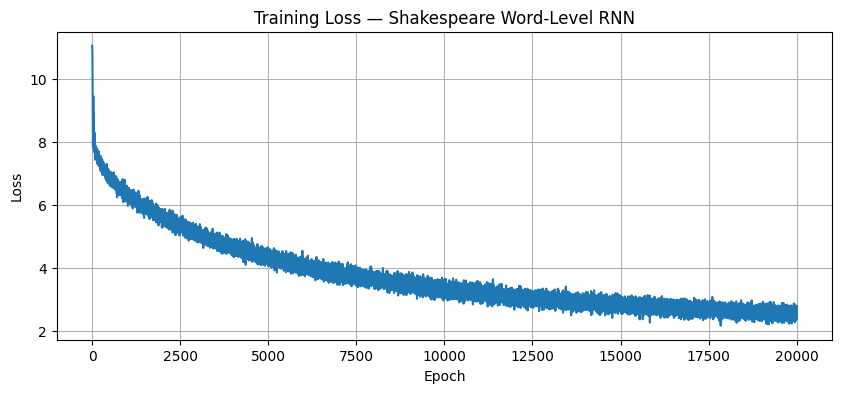

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss — Shakespeare Word-Level RNN')
plt.grid(True)
plt.savefig('loss_curve.png', dpi=150)
plt.show()

## 8. Text Generation

Text is generated autoregressively: starting from a prompt, the model predicts one word at a time. A sliding window of the last 50 words is maintained as context.

In [10]:
#text generation
def text_gen(model, start_str, length=200):
    model.eval()
    input_words = torch.tensor(encode(start_str), dtype=torch.long).unsqueeze(0).to(device)
    hidden = model.init_hidden(1)
    output_str = start_str

    with torch.no_grad():
        for _ in range(length):
            output, hidden = model(input_words, hidden)
            probs = F.softmax(output[:, -1, :], dim=1)
            next_char = torch.multinomial(probs, num_samples=1).item()
            output_str += ' ' + itos[next_char]
            input_words = torch.cat([
                input_words,
                torch.tensor([[next_char]], dtype=torch.long).to(device)
            ], dim=1)
            if input_words.shape[1] > block_size:
                input_words = input_words[:, -block_size:]

    return output_str

## 9. Results

In [11]:
prompts = ['ROMEO:', 'HAMLET:', 'JULIET:', 'to be']
for p in prompts:
    print(text_gen(model, p, length=50))
    print()


ROMEO: not! nothing but an heir to this place; i'll say at home, and what is he, that you are fools led me? should not my hand from me with men's eyes, hearing nothing more than all the mud are in arms. marcius. i'll have thought it possible that doubt no

HAMLET: alcibiades. how many children up farther, in thy husband and henry the sixth but you unfold the office, which such a malady as you. coriolanus: things have drown'd an army shallow. old play, mamillius; hamlet, faith; the beggars of his thoughts; and a tailor come, you are free and be

JULIET: some more fool i; but for your cause. campeius. my lord, for the wise, but, as is the falcon's piercing upon his court to mart all on the purpose. if alive to live, whose breath of every thing as faults by that my manners at my neck, that my good

to be thus forsworn; so well as a pinch the heaven and their praises throng in the possession of dirt. and how they are as fast as a kiss we? and with all that stop nature take no darkness like

## 10. Save Model

In [12]:
torch.save(model.state_dict(), 'shakespeare_rnn.pt')
print("Model saved!")

Model saved!


In [13]:
import os
os.listdir('/kaggle/working/')

['loss_curve.png', 'shakespeare_rnn.pt', '__notebook__.ipynb']